Importing

In [49]:
import seaborn as sns # for ti tanic dataset
from sklearn.model_selection import train_test_split # for spliting the data
from sklearn.metrics import classification_report # for test results
from sklearn.tree import DecisionTreeClassifier # model1
from sklearn.neighbors import KNeighborsClassifier #model2
import matplotlib.pyplot as plt# for data visualization

Loading dataset

In [26]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Droping columns that are not usefull

In [27]:
data_frame = df[["pclass", "sex", "age", "sibsp", "parch", "fare", "adult_male", "alive", "alone", "survived"]]
data_frame.head()

,pclass,sex,age,sibsp,parch,fare,adult_male,alive,alone,survived
0,3,male,22.0,1,0,7.2500,True,no,False,0
1,1,female,38.0,1,0,71.2833,False,yes,False,1
2,3,female,26.0,0,0,7.9250,False,yes,True,1
3,1,female,35.0,1,0,53.1000,False,yes,False,1
4,3,male,35.0,0,0,8.0500,True,no,True,0


In [28]:
data_frame["sex"] = (data_frame["sex"] == "male").astype(int) # if male then 1 else 0
data_frame["adult_male"] = (data_frame["adult_male"] == True).astype(int) # if adult_male then 1 else 0
data_frame["alive"] = (data_frame["alive"] == "yes").astype(int) # if alive then 1 else 0
data_frame["alone"] = (data_frame["alone"] == True).astype(int) # if alone then 1 else 0
data_frame.dropna(inplace=True) # Droping null values
data_frame.head()

/tmp/ipython-input-1891607648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_frame["sex"] = (data_frame["sex"] == "male").astype(int) # if male then 1 else 0
/tmp/ipython-input-1891607648.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_frame["adult_male"] = (data_frame["adult_male"] == True).astype(int) # if adult_male then 1 else 0
/tmp/ipython-input-1891607648.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

,pclass,sex,age,sibsp,parch,fare,adult_male,alive,alone,survived
0,3,1,22.0,1,0,7.2500,1,0,0,0
1,1,0,38.0,1,0,71.2833,0,1,0,1
2,3,0,26.0,0,0,7.9250,0,1,1,1
3,1,0,35.0,1,0,53.1000,0,1,0,1
4,3,1,35.0,0,0,8.0500,1,0,1,0


In [45]:
display(data_frame.describe())

,pclass,sex,age,sibsp,parch,fare,adult_male,alive,alone,survived
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000
mean,2.236695,0.634454,29.699118,0.512605,0.431373,34.694514,0.578431,0.406162,0.565826,0.406162
std,0.838250,0.481921,14.526497,0.929783,0.853289,52.918930,0.494156,0.491460,0.495995,0.491460
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,20.125000,0.000000,0.000000,8.050000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,28.000000,0.000000,0.000000,15.741700,1.000000,0.000000,1.000000,0.000000
75%,3.000000,1.000000,38.000000,1.000000,1.000000,33.375000,1.000000,1.000000,1.000000,1.000000
max,3.000000,1.000000,80.000000,5.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000


Check for null values

In [48]:
display(data_frame.isnull().sum())

,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
adult_male,0
alive,0
alone,0
survived,0


In [47]:
display(data_frame.info())

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      714 non-null    int64  
 1   sex         714 non-null    int64  
 2   age         714 non-null    float64
 3   sibsp       714 non-null    int64  
 4   parch       714 non-null    int64  
 5   fare        714 non-null    float64
 6   adult_male  714 non-null    int64  
 7   alive       714 non-null    int64  
 8   alone       714 non-null    int64  
 9   survived    714 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 61.4 KB


None

Histogram for age distribution

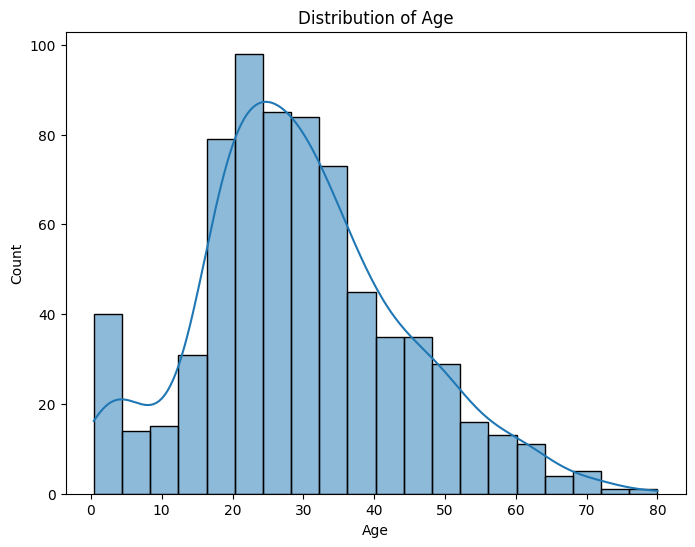

In [51]:
plt.figure(figsize=(8, 6))
sns.histplot(data_frame['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Survival rate of male and female

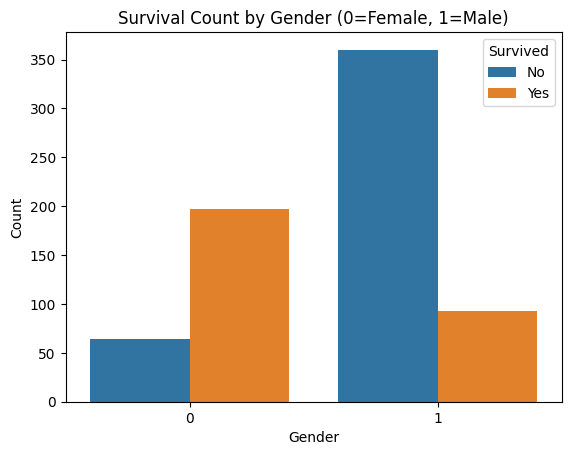

In [54]:
sns.countplot(x='sex', hue='survived', data=data_frame)
plt.title('Survival Count by Gender (0=Female, 1=Male)')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Getting X, Y

In [29]:
x = data_frame[data_frame.columns[:-1]]
y = data_frame[data_frame.columns[-1]]

Train, Test Split

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Model1: Decision Tree

In [31]:
clf = DecisionTreeClassifier(random_state=0).fit(x_train, y_train)
pre = clf.predict(x_test)

Classification report

In [32]:
print(classification_report(y_test, pre))
print("Test Score: ", clf.score(x_test, y_test))
print("Train Score: ", clf.score(x_train, y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00        56

    accuracy                           1.00       143
   macro avg       1.00      1.00      1.00       143
weighted avg       1.00      1.00      1.00       143

Test Score:  1.0
Train Score:  1.0


Model2: KNN

In [41]:
knn = KNeighborsClassifier(n_neighbors=5).fit(x_train, y_train)
pre = knn.predict(x_test)

Classification report

In [43]:
print(classification_report(y_test, pre))
print("Test Score: ", knn.score(x_test, y_test))
print("Train Score: ", knn.score(x_train, y_train))

              precision    recall  f1-score   support

           0       0.73      0.79      0.76        87
           1       0.63      0.55      0.59        56

    accuracy                           0.70       143
   macro avg       0.68      0.67      0.68       143
weighted avg       0.69      0.70      0.70       143

Test Score:  0.6993006993006993
Train Score:  0.8528896672504378
